In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score
from sklearn.model_selection import LeaveOneOut,KFold
from itertools import product

In [41]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
data = data.drop(columns = ['No.','Ref', 'Biomass','Catalyst'])

X= data.drop(['Gas yield','Oil yield', 'Char yield'], axis =1, inplace = False)
y = data['Oil yield']

In [42]:
para = {
    'n_estimators': [100,150,200],
    'max_depth':[4,5],
    'learning_rate': [0.1,0.01,0.2]
    }

para_comb = list(product(para['n_estimators']
                         ,para['max_depth'],para['learning_rate']))

In [43]:
mse_hist =[]
best_para = None
bmse = float('inf')


for n_estimators,max_depth,learning_rate in para_comb:
    model = CatBoostRegressor(n_estimators = n_estimators,
                          learning_rate = learning_rate,max_depth =max_depth,random_state = 42)
    loo = LeaveOneOut()

    mse_hist =[]
    for train_idx,test_idx in loo.split(y):
      x_train,y_train,x_test,y_test=X.iloc[train_idx],y.iloc[train_idx],X.iloc[test_idx],y.iloc[test_idx]

      model.fit(x_train,y_train)
      y_pred =model.predict(x_test)
      mse =mean_squared_error(y_test,y_pred)
      mse_hist.append(mse)

    mse= np.mean(mse_hist)

    if mse < bmse:
      bmse = mse
      best_para= {
                   'n_estimators' : n_estimators,
                   'learning_rate': learning_rate,
                   'max_depth': max_depth


      }


Streaming output truncated to the last 5000 lines.
0:	learn: 12.2408477	total: 628us	remaining: 125ms
1:	learn: 11.7012786	total: 1.12ms	remaining: 111ms
2:	learn: 11.0469804	total: 1.54ms	remaining: 101ms
3:	learn: 10.5138814	total: 1.96ms	remaining: 96ms
4:	learn: 9.9325438	total: 2.39ms	remaining: 93.3ms
5:	learn: 9.5675617	total: 2.78ms	remaining: 89.8ms
6:	learn: 9.2446459	total: 3.2ms	remaining: 88.2ms
7:	learn: 8.6977145	total: 3.58ms	remaining: 85.8ms
8:	learn: 8.5492206	total: 3.95ms	remaining: 83.8ms
9:	learn: 8.3100290	total: 4.31ms	remaining: 81.8ms
10:	learn: 8.1818680	total: 4.69ms	remaining: 80.6ms
11:	learn: 7.8212009	total: 5.08ms	remaining: 79.6ms
12:	learn: 7.6400361	total: 5.44ms	remaining: 78.3ms
13:	learn: 7.3617907	total: 5.83ms	remaining: 77.5ms
14:	learn: 7.2650252	total: 6.2ms	remaining: 76.4ms
15:	learn: 7.0773092	total: 6.6ms	remaining: 75.9ms
16:	learn: 6.9478166	total: 6.98ms	remaining: 75.1ms
17:	learn: 6.7975059	total: 7.34ms	remaining: 74.2ms
18:	learn:

0:	learn: 12.2142980	total: 571us	remaining: 56.6ms
1:	learn: 11.6758087	total: 1.26ms	remaining: 61.8ms
2:	learn: 11.0231362	total: 1.68ms	remaining: 54.4ms
3:	learn: 10.4913024	total: 2.08ms	remaining: 50ms
4:	learn: 9.9127271	total: 2.49ms	remaining: 47.3ms
5:	learn: 9.5483417	total: 2.88ms	remaining: 45.1ms
6:	learn: 9.2262318	total: 3.26ms	remaining: 43.3ms
7:	learn: 8.6802432	total: 3.63ms	remaining: 41.8ms
8:	learn: 8.3790407	total: 4.01ms	remaining: 40.5ms
9:	learn: 8.0959285	total: 4.39ms	remaining: 39.5ms
10:	learn: 7.9362955	total: 4.76ms	remaining: 38.5ms
11:	learn: 7.7470858	total: 5.13ms	remaining: 37.6ms
12:	learn: 7.5624040	total: 5.48ms	remaining: 36.7ms
13:	learn: 7.3662913	total: 5.86ms	remaining: 36ms
14:	learn: 7.2726634	total: 6.24ms	remaining: 35.3ms
15:	learn: 7.0800853	total: 6.6ms	remaining: 34.7ms
16:	learn: 6.9546760	total: 6.98ms	remaining: 34.1ms
17:	learn: 6.7779408	total: 7.34ms	remaining: 33.4ms
18:	learn: 6.6636119	total: 7.71ms	remaining: 32.9ms
19:	l

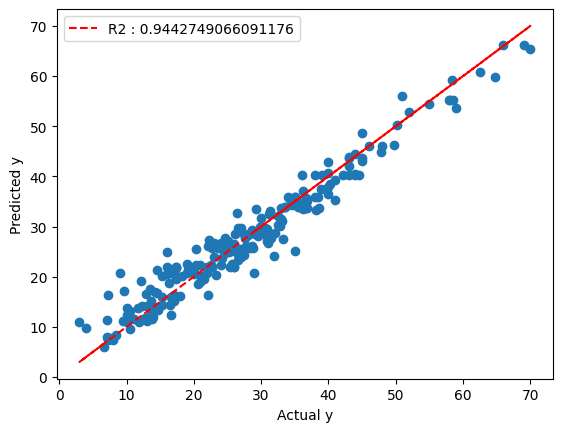

In [44]:
best_model = CatBoostRegressor(**best_para,random_state=42)

best_model.fit(X,y)
y_pred = best_model.predict(X)

mse = mean_squared_error(y,y_pred)
mae = mean_absolute_error(y,y_pred)
r2 = r2_score(y,y_pred)

print(best_para)
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')

plt.plot(y,y,'r--',label = 'Ideal')
plt.scatter(y,y_pred,label= 'Predicted values')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.legend([f'R2 : {r2}'])
plt.show()